# <span style="color:#cc416d">Validacion perfil 2D vs celdas DEM</span>

In [1]:
import math
import matplotlib.pyplot as plt
from qgis.core import (
    QgsRasterLayer,
    QgsVectorLayer,
    QgsGeometry,
    QgsPointXY,
    QgsRectangle
)



### <span style="color:#cc416d">1. Carga de datos</span>

In [2]:
ruta_dem = r"C:\Proyectos\2026\seccion\dem2.tif"

ruta_linea_perfil = (
    r"C:\Proyectos\2026\seccion\salidas"
    r"\ejemplo_seccion3_guia.shp"
)

### <span style="color:#cc416d">2. Cargar DEM y línea</span>

In [4]:
dem_layer = QgsRasterLayer(
    ruta_dem,
    "DEM"
)

linea_layer = QgsVectorLayer(
    ruta_linea_perfil,
    "Linea_perfil",
    "ogr"
)

print("DEM válido:", dem_layer.isValid())
print("Línea válida:", linea_layer.isValid())

print("CRS DEM:", dem_layer.crs().authid())
print("CRS línea:", linea_layer.crs().authid())

DEM válido: True
Línea válida: True
CRS DEM: EPSG:6368
CRS línea: EPSG:6368


### <span style="color:#cc416d">3.  Obtener la geometría</span>

In [5]:
features_linea = list(linea_layer.getFeatures())

print("Cantidad de entidades:", len(features_linea))

if not features_linea:
    raise Exception("La capa de línea no contiene entidades.")

feature_linea = features_linea[0]
geom_linea = feature_linea.geometry()

if geom_linea is None or geom_linea.isEmpty():
    raise Exception("La geometría de la línea está vacía.")

print("Longitud de la línea:", geom_linea.length())
print("Multipart:", geom_linea.isMultipart())
print("Vértices originales:", len(list(geom_linea.vertices())))

Cantidad de entidades: 1
Longitud de la línea: 5772.659572948623
Multipart: True
Vértices originales: 2


### <span style="color:#cc416d">4. Propiedades del DEM</span>

In [6]:
provider_dem = dem_layer.dataProvider()

extent_dem = dem_layer.extent()

pixel_x = abs(dem_layer.rasterUnitsPerPixelX())
pixel_y = abs(dem_layer.rasterUnitsPerPixelY())

ancho_dem = dem_layer.width()
alto_dem = dem_layer.height()

print("Tamaño píxel X:", pixel_x)
print("Tamaño píxel Y:", pixel_y)

print("Columnas:", ancho_dem)
print("Filas:", alto_dem)

print("Extent DEM:")
print("xmin:", extent_dem.xMinimum())
print("xmax:", extent_dem.xMaximum())
print("ymin:", extent_dem.yMinimum())
print("ymax:", extent_dem.yMaximum())

Tamaño píxel X: 5.0
Tamaño píxel Y: 5.0
Columnas: 1243
Filas: 1455
Extent DEM:
xmin: 616700.0
xmax: 622915.0
ymin: 2107955.0
ymax: 2115230.0


### <span style="color:#cc416d">5. Construir el perfil actual de SecGeol</span>

In [7]:
distancia_densificada = min(pixel_x, pixel_y)

geom_densificada = geom_linea.densifyByDistance(
    distancia_densificada
)

vertices_densificados = list(
    geom_densificada.vertices()
)

print(
    "Distancia usada para densificar:",
    distancia_densificada
)

print(
    "Cantidad de vértices densificados:",
    len(vertices_densificados)
)

Distancia usada para densificar: 5.0
Cantidad de vértices densificados: 1156


#### <span style="color:#cc416d">calculamos distancia y elevación</span>

In [8]:
perfil_secgeol = []

dist_acum = 0.0
prev_pt = None

for indice, pt in enumerate(vertices_densificados):

    if prev_pt is not None:
        dx = pt.x() - prev_pt.x()
        dy = pt.y() - prev_pt.y()

        dist_acum += math.sqrt(
            dx**2 + dy**2
        )

    elevacion, ok = provider_dem.sample(
        QgsPointXY(pt.x(), pt.y()),
        1
    )

    if not ok or elevacion is None:
        raise Exception(
            f"No fue posible muestrear el DEM "
            f"en el punto {indice}."
        )

    perfil_secgeol.append({
        "indice": indice,
        "distancia": dist_acum,
        "elevacion": elevacion,
        "x": pt.x(),
        "y": pt.y()
    })

    prev_pt = pt

#### <span style="color:#cc416d">Imprimimos el resumen:</span> 

In [9]:
print("Puntos perfil SecGeol:", len(perfil_secgeol))

print(
    "Distancia inicial:",
    perfil_secgeol[0]["distancia"]
)

print(
    "Distancia final:",
    perfil_secgeol[-1]["distancia"]
)

print(
    "Elevación mínima:",
    min(p["elevacion"] for p in perfil_secgeol)
)

print(
    "Elevación máxima:",
    max(p["elevacion"] for p in perfil_secgeol)
)

Puntos perfil SecGeol: 1156
Distancia inicial: 0.0
Distancia final: 5772.659572948555
Elevación mínima: 186.22000122070312
Elevación máxima: 699.5700073242188


## <span style="color:#cc416d">Ahora viene el Perfil B</span>  

Para obtener las celdas atravesadas, propongo hacerlo de forma controlada:

- Calcular qué filas y columnas cubre el bounding box de la línea.
- Construir únicamente esas celdas.
- Comprobar cuáles intersectan realmente la línea.
- Obtener el valor raster de cada celda.
- Asignar una distancia sobre la línea.
- Ordenarlas de inicio a fin.

La siguiente celda será la base para convertir coordenadas XY en fila y columna del raster.

## <span style="color:#cc416d">6. Funciones fila-columna</span>  

In [10]:
def xy_a_columna_fila(
    x,
    y,
    extent,
    pixel_x,
    pixel_y
):
    columna = int(
        math.floor(
            (x - extent.xMinimum()) / pixel_x
        )
    )

    fila = int(
        math.floor(
            (extent.yMaximum() - y) / pixel_y
        )
    )

    return columna, fila

## <span style="color:#cc416d">7. Función contraria, para obtener la extensión de una celda:</span>   

In [11]:
def extent_celda(
    columna,
    fila,
    extent,
    pixel_x,
    pixel_y
):
    xmin = (
        extent.xMinimum()
        + columna * pixel_x
    )

    xmax = xmin + pixel_x

    ymax = (
        extent.yMaximum()
        - fila * pixel_y
    )

    ymin = ymax - pixel_y

    return QgsRectangle(
        xmin,
        ymin,
        xmax,
        ymax
    )

## <span style="color:#cc416d">8. Rango de filas y columnas a revisar</span>   

In [12]:
bbox_linea = geom_linea.boundingBox()

col_min, fila_max = xy_a_columna_fila(
    bbox_linea.xMinimum(),
    bbox_linea.yMinimum(),
    extent_dem,
    pixel_x,
    pixel_y
)

col_max, fila_min = xy_a_columna_fila(
    bbox_linea.xMaximum(),
    bbox_linea.yMaximum(),
    extent_dem,
    pixel_x,
    pixel_y
)

col_min = max(0, col_min)
col_max = min(ancho_dem - 1, col_max)

fila_min = max(0, fila_min)
fila_max = min(alto_dem - 1, fila_max)

print("Columnas a revisar:", col_min, "a", col_max)
print("Filas a revisar:", fila_min, "a", fila_max)

print(
    "Número aproximado de celdas candidatas:",
    (col_max - col_min + 1)
    * (fila_max - fila_min + 1)
)

Columnas a revisar: 90 a 1210
Filas a revisar: 292 a 572
Número aproximado de celdas candidatas: 315001


## <span style="color:#cc416d">Celda 9. Recorrer las celdas atravesadas</span>   

In [13]:
def recorrer_celdas_linea(
    geom_linea,
    extent,
    pixel_x,
    pixel_y,
    n_columnas,
    n_filas
):
    vertices = list(geom_linea.vertices())

    if len(vertices) != 2:
        raise Exception(
            "Esta versión de la prueba está preparada "
            "para una línea simple de dos vértices."
        )

    p0 = vertices[0]
    p1 = vertices[1]

    x0, y0 = p0.x(), p0.y()
    x1, y1 = p1.x(), p1.y()

    dx = x1 - x0
    dy = y1 - y0

    col, fila = xy_a_columna_fila(
        x0,
        y0,
        extent,
        pixel_x,
        pixel_y
    )

    col_fin, fila_fin = xy_a_columna_fila(
        x1,
        y1,
        extent,
        pixel_x,
        pixel_y
    )

    if not (
        0 <= col < n_columnas
        and 0 <= fila < n_filas
        and 0 <= col_fin < n_columnas
        and 0 <= fila_fin < n_filas
    ):
        raise Exception(
            "Uno de los extremos de la línea está fuera del DEM."
        )

    paso_col = 0
    paso_fila = 0

    if dx > 0:
        paso_col = 1
    elif dx < 0:
        paso_col = -1

    if dy > 0:
        paso_fila = -1
    elif dy < 0:
        paso_fila = 1

    infinito = float("inf")

    # Parámetro t: 0 al inicio, 1 al final
    if paso_col != 0:
        if paso_col > 0:
            siguiente_x = (
                extent.xMinimum()
                + (col + 1) * pixel_x
            )
        else:
            siguiente_x = (
                extent.xMinimum()
                + col * pixel_x
            )

        t_max_x = (siguiente_x - x0) / dx
        t_delta_x = pixel_x / abs(dx)
    else:
        t_max_x = infinito
        t_delta_x = infinito

    if paso_fila != 0:
        if paso_fila > 0:
            # Avance hacia el sur
            siguiente_y = (
                extent.yMaximum()
                - (fila + 1) * pixel_y
            )
        else:
            # Avance hacia el norte
            siguiente_y = (
                extent.yMaximum()
                - fila * pixel_y
            )

        t_max_y = (siguiente_y - y0) / dy
        t_delta_y = pixel_y / abs(dy)
    else:
        t_max_y = infinito
        t_delta_y = infinito

    celdas = []
    t_entrada = 0.0

    while True:
        if t_max_x < t_max_y:
            t_salida = min(t_max_x, 1.0)
            eje_salida = "x"
        elif t_max_y < t_max_x:
            t_salida = min(t_max_y, 1.0)
            eje_salida = "y"
        else:
            t_salida = min(t_max_x, 1.0)
            eje_salida = "xy"

        celdas.append({
            "columna": col,
            "fila": fila,
            "t_entrada": max(0.0, t_entrada),
            "t_salida": min(1.0, t_salida)
        })

        if col == col_fin and fila == fila_fin:
            break

        if eje_salida == "x":
            col += paso_col
            t_entrada = t_max_x
            t_max_x += t_delta_x

        elif eje_salida == "y":
            fila += paso_fila
            t_entrada = t_max_y
            t_max_y += t_delta_y

        else:
            # Cruza exactamente una esquina de celda
            col += paso_col
            fila += paso_fila
            t_entrada = t_max_x
            t_max_x += t_delta_x
            t_max_y += t_delta_y

        if not (
            0 <= col < n_columnas
            and 0 <= fila < n_filas
        ):
            raise Exception(
                "El recorrido salió de los límites del DEM."
            )

    return celdas

## <span style="color:#cc416d">Celda 10. Ejecutar el recorrido</span>   

In [14]:
celdas_atravesadas = recorrer_celdas_linea(
    geom_linea=geom_linea,
    extent=extent_dem,
    pixel_x=pixel_x,
    pixel_y=pixel_y,
    n_columnas=ancho_dem,
    n_filas=alto_dem
)

print(
    "Cantidad de celdas atravesadas:",
    len(celdas_atravesadas)
)

print("\nPrimeras celdas:")
for celda in celdas_atravesadas[:10]:
    print(celda)

print("\nÚltimas celdas:")
for celda in celdas_atravesadas[-10:]:
    print(celda)

Cantidad de celdas atravesadas: 1401

Primeras celdas:
{'columna': 90, 'fila': 292, 't_entrada': 0.0, 't_salida': 0.0006616421537612698}
{'columna': 90, 'fila': 293, 't_entrada': 0.0006616421537612698, 't_salida': 0.0008526630489455208}
{'columna': 91, 'fila': 293, 't_entrada': 0.0008526630489455208, 't_salida': 0.0017453483113175098}
{'columna': 92, 'fila': 293, 't_entrada': 0.0017453483113175098, 't_salida': 0.002638033573689499}
{'columna': 93, 'fila': 293, 't_entrada': 0.002638033573689499, 't_salida': 0.003530718836061488}
{'columna': 94, 'fila': 293, 't_entrada': 0.003530718836061488, 't_salida': 0.004240820849871684}
{'columna': 94, 'fila': 294, 't_entrada': 0.004240820849871684, 't_salida': 0.004423404098433477}
{'columna': 95, 'fila': 294, 't_entrada': 0.004423404098433477, 't_salida': 0.005316089360805467}
{'columna': 96, 'fila': 294, 't_entrada': 0.005316089360805467, 't_salida': 0.006208774623177456}
{'columna': 97, 'fila': 294, 't_entrada': 0.006208774623177456, 't_salida'

## <span style="color:#cc416d">Celda 11. Construir el perfil por celdas</span>   

In [15]:
longitud_linea = geom_linea.length()

perfil_celdas = []

for indice, celda in enumerate(celdas_atravesadas):

    t_medio = (
        celda["t_entrada"]
        + celda["t_salida"]
    ) / 2.0

    distancia_media = t_medio * longitud_linea

    punto_medio_geom = geom_linea.interpolate(
        distancia_media
    )

    if punto_medio_geom.isEmpty():
        raise Exception(
            f"No fue posible interpolar la celda {indice}."
        )

    punto_medio = punto_medio_geom.asPoint()

    elevacion, ok = provider_dem.sample(
        QgsPointXY(
            punto_medio.x(),
            punto_medio.y()
        ),
        1
    )

    if not ok or elevacion is None:
        raise Exception(
            f"No fue posible muestrear la celda {indice}, "
            f"fila={celda['fila']}, "
            f"columna={celda['columna']}."
        )

    perfil_celdas.append({
        "indice": indice,
        "fila": celda["fila"],
        "columna": celda["columna"],
        "distancia": distancia_media,
        "dist_entrada": (
            celda["t_entrada"]
            * longitud_linea
        ),
        "dist_salida": (
            celda["t_salida"]
            * longitud_linea
        ),
        "elevacion": elevacion,
        "x": punto_medio.x(),
        "y": punto_medio.y()
    })

In [16]:
print("Puntos del perfil por celdas:", len(perfil_celdas))

print(
    "Primera distancia media:",
    perfil_celdas[0]["distancia"]
)

print(
    "Última distancia media:",
    perfil_celdas[-1]["distancia"]
)

print(
    "Elevación mínima:",
    min(p["elevacion"] for p in perfil_celdas)
)

print(
    "Elevación máxima:",
    max(p["elevacion"] for p in perfil_celdas)
)

Puntos del perfil por celdas: 1401
Primera distancia media: 1.9097174563881694
Última distancia media: 5771.9884194261285
Elevación mínima: 185.8800048828125
Elevación máxima: 699.5700073242188


- 1401 celdas atravesadas, frente a 1156 puntos densificados.
- Primera posición representativa a 1.91 m, porque usamos el punto medio del tramo dentro de la primera celda.
- Última a 5771.99 m, muy cerca de la longitud total de 5772.66 m.
- Rango de elevaciones: 185.88–699.57 m.



## <span style="color:#cc416d">Celda 12. Graficar los dos perfiles</span>   

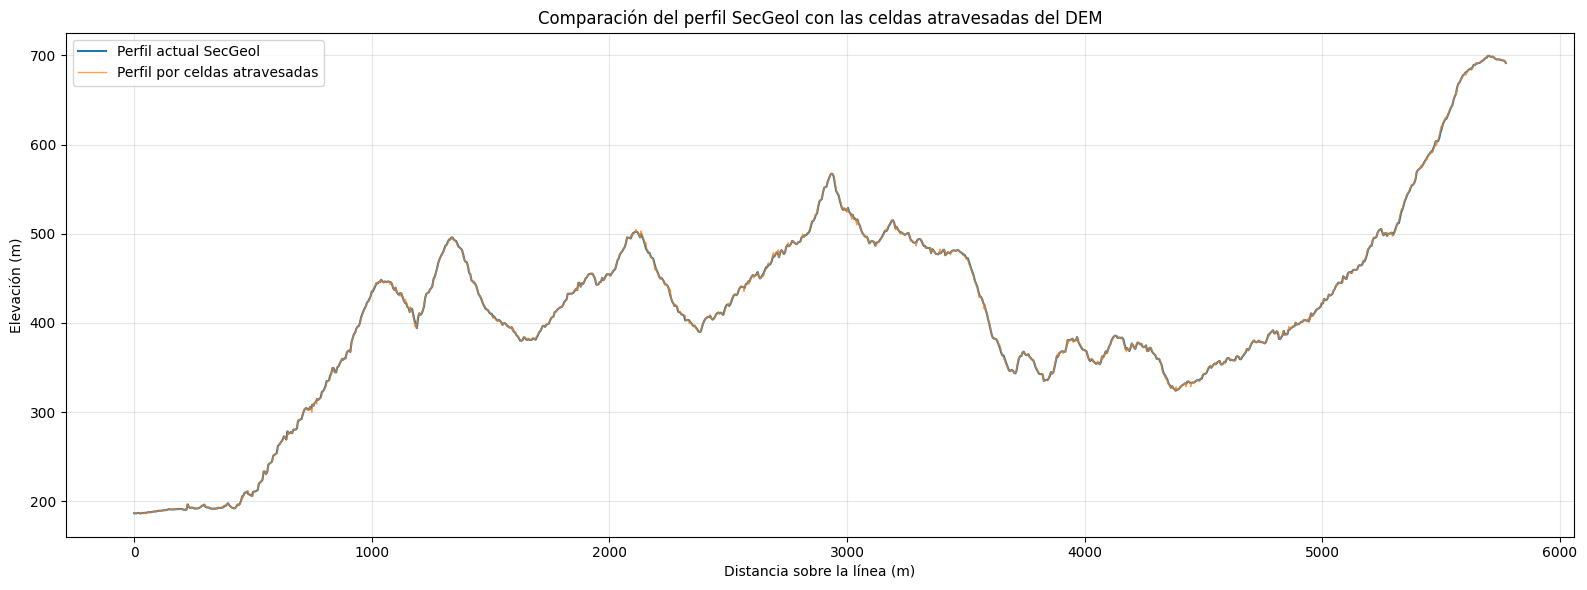

In [17]:
dist_secgeol = [
    p["distancia"]
    for p in perfil_secgeol
]

z_secgeol = [
    p["elevacion"]
    for p in perfil_secgeol
]

dist_celdas = [
    p["distancia"]
    for p in perfil_celdas
]

z_celdas = [
    p["elevacion"]
    for p in perfil_celdas
]

plt.figure(figsize=(16, 6))

plt.plot(
    dist_secgeol,
    z_secgeol,
    linewidth=1.5,
    label="Perfil actual SecGeol"
)

plt.plot(
    dist_celdas,
    z_celdas,
    linewidth=1.0,
    alpha=0.75,
    label="Perfil por celdas atravesadas"
)

plt.xlabel("Distancia sobre la línea (m)")
plt.ylabel("Elevación (m)")
plt.title(
    "Comparación del perfil SecGeol "
    "con las celdas atravesadas del DEM"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## <span style="color:#cc416d">Celda 13. Acercamiento a la cima principal</span>   

In [18]:
max_secgeol = max(
    perfil_secgeol,
    key=lambda p: p["elevacion"]
)

max_celdas = max(
    perfil_celdas,
    key=lambda p: p["elevacion"]
)

print("Máximo SecGeol:")
print(
    "Distancia:",
    max_secgeol["distancia"],
    "Elevación:",
    max_secgeol["elevacion"]
)

print("\nMáximo por celdas:")
print(
    "Distancia:",
    max_celdas["distancia"],
    "Elevación:",
    max_celdas["elevacion"]
)

print(
    "\nDiferencia horizontal entre máximos:",
    max_secgeol["distancia"]
    - max_celdas["distancia"],
    "m"
)

Máximo SecGeol:
Distancia: 5697.689968105001 Elevación: 699.5700073242188

Máximo por celdas:
Distancia: 5696.59632808444 Elevación: 699.5700073242188

Diferencia horizontal entre máximos: 1.093640020560997 m


### <span style="color:#cc416d">Dibujamos una ventana alrededor de ambos máximos</span>   

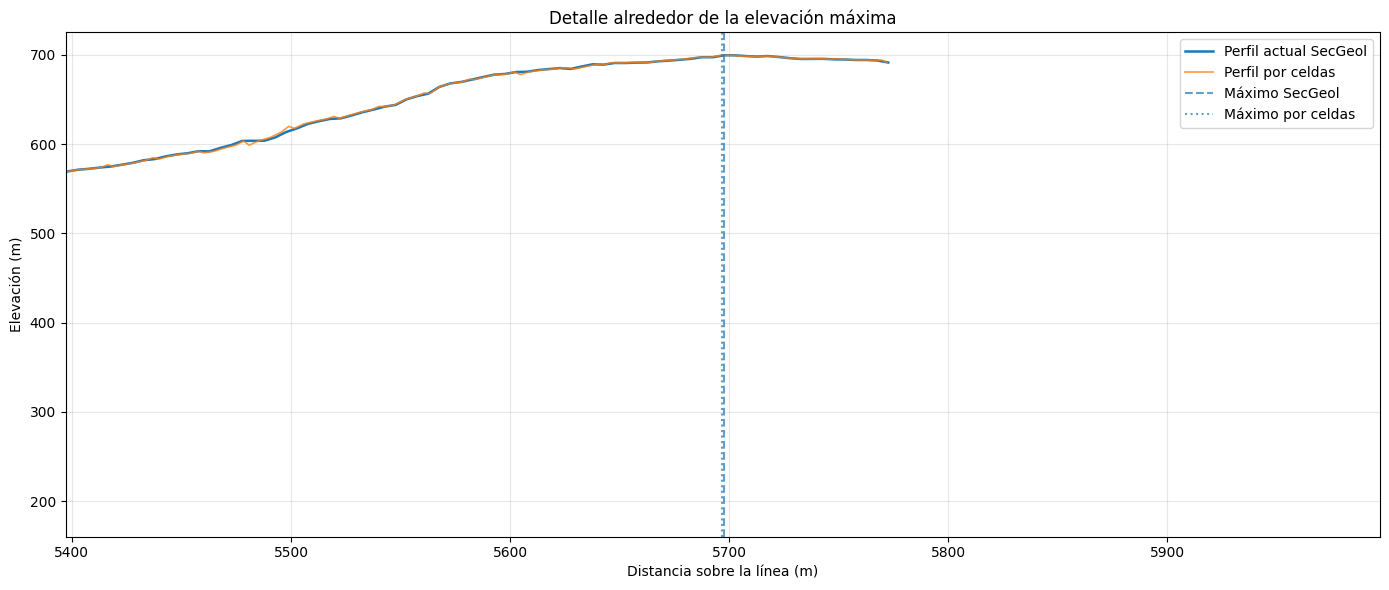

In [19]:
centro_maximo = (
    max_secgeol["distancia"]
    + max_celdas["distancia"]
) / 2.0

margen = 300.0

plt.figure(figsize=(14, 6))

plt.plot(
    dist_secgeol,
    z_secgeol,
    linewidth=1.8,
    label="Perfil actual SecGeol"
)

plt.plot(
    dist_celdas,
    z_celdas,
    linewidth=1.2,
    alpha=0.8,
    label="Perfil por celdas"
)

plt.axvline(
    max_secgeol["distancia"],
    linestyle="--",
    alpha=0.7,
    label="Máximo SecGeol"
)

plt.axvline(
    max_celdas["distancia"],
    linestyle=":",
    alpha=0.7,
    label="Máximo por celdas"
)

plt.xlim(
    centro_maximo - margen,
    centro_maximo + margen
)

plt.xlabel("Distancia sobre la línea (m)")
plt.ylabel("Elevación (m)")
plt.title("Detalle alrededor de la elevación máxima")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### <span style="color:#cc416d">Una comparación numérica más justa</span>   
No debemos restar directamente ambas listas porque tienen distinto número de puntos. Interpolaremos el perfil de celdas en las distancias de SecGeol:

In [20]:
import numpy as np

dist_secgeol_np = np.array(
    dist_secgeol,
    dtype=float
)

z_secgeol_np = np.array(
    z_secgeol,
    dtype=float
)

dist_celdas_np = np.array(
    dist_celdas,
    dtype=float
)

z_celdas_np = np.array(
    z_celdas,
    dtype=float
)

z_celdas_interp = np.interp(
    dist_secgeol_np,
    dist_celdas_np,
    z_celdas_np
)

diferencia_z = (
    z_secgeol_np
    - z_celdas_interp
)

print(
    "Diferencia Z mínima:",
    diferencia_z.min()
)

print(
    "Diferencia Z máxima:",
    diferencia_z.max()
)

print(
    "Diferencia Z media absoluta:",
    np.mean(np.abs(diferencia_z))
)

print(
    "RMSE:",
    np.sqrt(
        np.mean(diferencia_z ** 2)
    )
)

Diferencia Z mínima: -4.872923271474804
Diferencia Z máxima: 6.743217209685611
Diferencia Z media absoluta: 0.5602481318543509
RMSE: 0.879360075391556


### <span style="color:#cc416d">Curva de diferencias</span>   

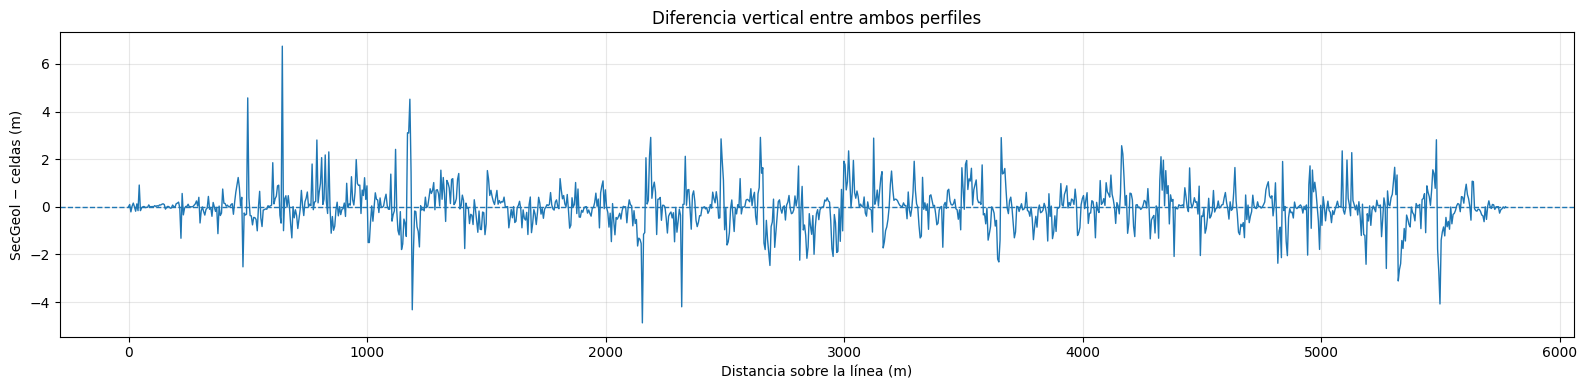

In [21]:
plt.figure(figsize=(16, 4))

plt.plot(
    dist_secgeol_np,
    diferencia_z,
    linewidth=1.0
)

plt.axhline(
    0.0,
    linewidth=1.0,
    linestyle="--"
    
)

plt.xlabel("Distancia sobre la línea (m)")
plt.ylabel("SecGeol − celdas (m)")
plt.title(
    "Diferencia vertical entre ambos perfiles"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<h3>Interpretación visual de las curvas</h3>

<p>
La comparación gráfica muestra que el perfil construido por SecGeol y el perfil
obtenido mediante el recorrido directo de las celdas atravesadas por la línea
presentan una correspondencia muy alta.
</p>

<p>
En la gráfica general, ambas curvas se superponen prácticamente a lo largo de toda
la sección. Las principales elevaciones, depresiones y cambios de pendiente aparecen
en las mismas posiciones horizontales, sin observarse una separación progresiva,
un corrimiento constante ni una deformación sistemática del relieve.
</p>

<p>
Las pequeñas diferencias visibles en algunos tramos corresponden a variaciones locales
asociadas con la manera en que cada método representa el raster:
</p>

<ul>
    <li>
        SecGeol muestrea el DEM en vértices densificados distribuidos regularmente
        sobre la línea.
    </li>
    <li>
        El segundo método utiliza el punto medio del tramo atravesado dentro de cada
        celda del DEM.
    </li>
</ul>

<p>
Por lo tanto, ambos métodos pueden seleccionar posiciones ligeramente distintas
dentro de una misma celda o en celdas contiguas, especialmente en zonas con cambios
rápidos de elevación. Estas diferencias son locales y no representan un desplazamiento
horizontal general del perfil.
</p>

<h3>Detalle de la elevación máxima</h3>

<p>
El acercamiento a la zona de máxima elevación confirma la coincidencia entre ambas
curvas. Los dos perfiles alcanzan una elevación máxima de
<strong>699.57 m</strong>.
</p>

<p>
La posición del máximo fue:
</p>

<ul>
    <li>
        <strong>Perfil SecGeol:</strong> 5697.690 m.
    </li>
    <li>
        <strong>Perfil por celdas:</strong> 5696.596 m.
    </li>
</ul>

<p>
La diferencia horizontal fue de únicamente <strong>1.094 m</strong>, equivalente
a aproximadamente <strong>0.22 píxeles</strong> para un DEM con resolución de 5 m.
Esta diferencia se considera compatible con la discretización espacial del raster
y con la distinta posición representativa utilizada por cada procedimiento.
</p>

<h3>Interpretación de la gráfica de diferencias verticales</h3>

<p>
La gráfica de diferencias representa, para cada distancia del perfil, el valor:
</p>

<p style="text-align: center;">
    <strong>&Delta;Z = Z<sub>SecGeol</sub> - Z<sub>celdas</sub></strong>
</p>

<p>
Los valores positivos indican que, en esa posición, SecGeol obtuvo una elevación
ligeramente mayor. Los valores negativos indican que la elevación de SecGeol fue
ligeramente menor.
</p>

<p>
La curva oscila alrededor de cero durante toda la sección y no presenta una tendencia
creciente, decreciente o sostenida. Esto demuestra que no existe un sesgo vertical
general entre ambos perfiles.
</p>

<p>
Los picos aislados, con valores aproximados entre −4.87 y 6.74 m, se concentran en
sectores donde el relieve cambia de manera rápida. La diferencia media absoluta fue
de <strong>0.56 m</strong> y el RMSE fue de <strong>0.88 m</strong>, valores reducidos
en comparación con la resolución espacial del DEM.
</p>



<div style="
    border-left: 5px solid #3c78d8;
    background-color: #f3f6fa;
    padding: 12px 16px;
    margin-top: 15px;
">
    <p style="margin: 0;">
        <strong>Conclusión de la Etapa 3:</strong>
        el perfil topográfico generado por SecGeol reproduce correctamente el relieve
        del DEM. No se observa un desplazamiento horizontal sistemático, ni una
        deformación significativa, ni una diferencia vertical persistente respecto
        del perfil construido a partir de las celdas atravesadas.
    </p>
    
<p style="margin-bottom: 0;">
        En consecuencia, el posible desfase observado en el producto final no se
        origina en la densificación, el muestreo del DEM ni la construcción del
        perfil topográfico 2D. La siguiente revisión debe concentrarse en la
        reconstrucción espacial del perfil 3D y en las geometrías generadas a partir
        de las distancias del perfil.
    </p>
    
</div>